In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import glob


### ics.uci.edu-755

- Line 20930 in the dataset was modified (timestamp was in datetime format)

It seems like this dataset has only "walking" data (over 98%). Most likely unusable for our purposes

In [33]:
df = pd.read_csv("../data/ics.uci.edu-755/dataset.csv")

In [34]:
# Count distribution
activity_counts = df['Activity'].value_counts().sort_index()

# Display counts and percentages
for activity, count in activity_counts.items():
    label = "Standing (0)" if activity == 0 else "Walking (1)"
    percentage = count / len(df) * 100
    print(f"{label}: {count} samples ({percentage:.2f}%)")


Standing (0): 571 samples (1.78%)
Walking (1): 31420 samples (98.22%)


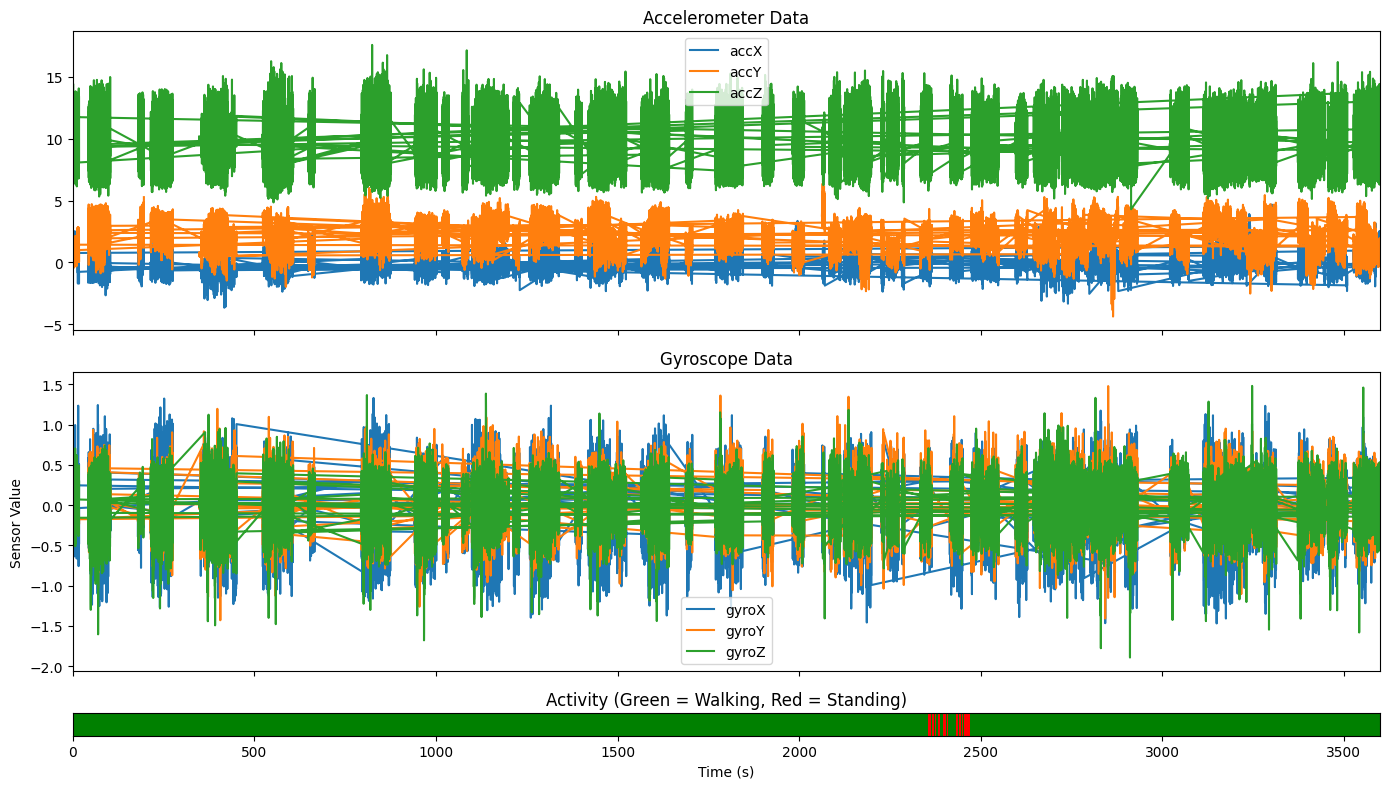

In [35]:


# Parse MM:SS.s to seconds
def parse_time(t):
    minutes, seconds = t.split(":")
    return int(minutes) * 60 + float(seconds)

df['time_sec'] = df['timestamp'].apply(parse_time)

# Create a numeric array for activity (0 or 1)
activity_array = df['Activity'].values.reshape(1, -1)

# Custom color map: 0 = red, 1 = green
cmap = mcolors.ListedColormap(['red', 'green'])

# Plot
fig, axs = plt.subplots(3, 1, figsize=(14, 8), sharex=True,
                        gridspec_kw={"height_ratios": [4, 4, 0.3]})

# Accelerometer
axs[0].set_title("Accelerometer Data")
for axis in ['accX', 'accY', 'accZ']:
    axs[0].plot(df['time_sec'], df[axis], label=axis)
axs[0].legend()

# Gyroscope
axs[1].set_title("Gyroscope Data")
for axis in ['gyroX', 'gyroY', 'gyroZ']:
    axs[1].plot(df['time_sec'], df[axis], label=axis)
axs[1].legend()

# Activity strip
axs[2].imshow(activity_array, aspect='auto', cmap=cmap,
              extent=[df['time_sec'].min(), df['time_sec'].max(), 0, 1])
axs[2].set_yticks([])
axs[2].set_title("Activity (Green = Walking, Red = Standing)")

# Labels
axs[1].set_ylabel("Sensor Value")
axs[2].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

### Kaggle-vmalyi

- This dataset labels Walking and Running. Could still be useful visually
- First code snippet resaves the file, merging the date + time into timestamp and removing the user column

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import glob


In [37]:

# Load original dataset
df = pd.read_csv("../data/kaggle-vmalyi/dataset.csv")

# Replace last ':' in time with '.' to match standard datetime format
df['time'] = df['time'].str.replace(r':(?=\d{6,9}$)', '.', regex=True)

# Combine date and time into a single timestamp
df['timestamp'] = pd.to_datetime(df['date'] + ' ' + df['time'], errors='coerce')

# Drop original date, time, and username columns
df_cleaned = df.drop(columns=['date', 'time', 'username'])

# Optional: move timestamp to front
cols = ['timestamp'] + [col for col in df_cleaned.columns if col != 'timestamp']
df_cleaned = df_cleaned[cols]

# Save to a new CSV
df_cleaned.to_csv("../data/kaggle-vmalyi/clean_dataset.csv", index=False)

activity_counts = df['activity'].value_counts().sort_index()

# Print out the results
for activity, count in activity_counts.items():
    label = "Walking (0)" if activity == 0 else "Running (1)"
    percentage = count / len(df) * 100
    print(f"{label}: {count} samples ({percentage:.2f}%)")

print("Cleaned dataset saved as 'clean_dataset.csv'")


Walking (0): 44223 samples (49.92%)
Running (1): 44365 samples (50.08%)
Cleaned dataset saved as 'clean_dataset.csv'


This data must be split into segments, because it holds separate recording sessions

In [38]:
# Load cleaned dataset (timestamp must already be parsed as datetime)
df = pd.read_csv("../data/kaggle-vmalyi/clean_dataset.csv", parse_dates=['timestamp'])

# Sort by timestamp just in case
df = df.sort_values('timestamp')

# Compute time differences between rows (in seconds)
df['delta'] = df['timestamp'].diff().dt.total_seconds()

# Define a threshold (e.g., anything above 1 sec is a new session)
threshold = 60.0

# Identify segment boundaries
segment_id = (df['delta'] > threshold).cumsum()
df['segment'] = segment_id

# Save each segment into a separate file
for seg in df['segment'].unique():
    segment_df = df[df['segment'] == seg].drop(columns=['delta', 'segment'])
    segment_df.to_csv(f"../data/kaggle-vmalyi/segments/segment_{seg}.csv", index=False)

print(f"Saved {df['segment'].nunique()} segments.")

Saved 41 segments.


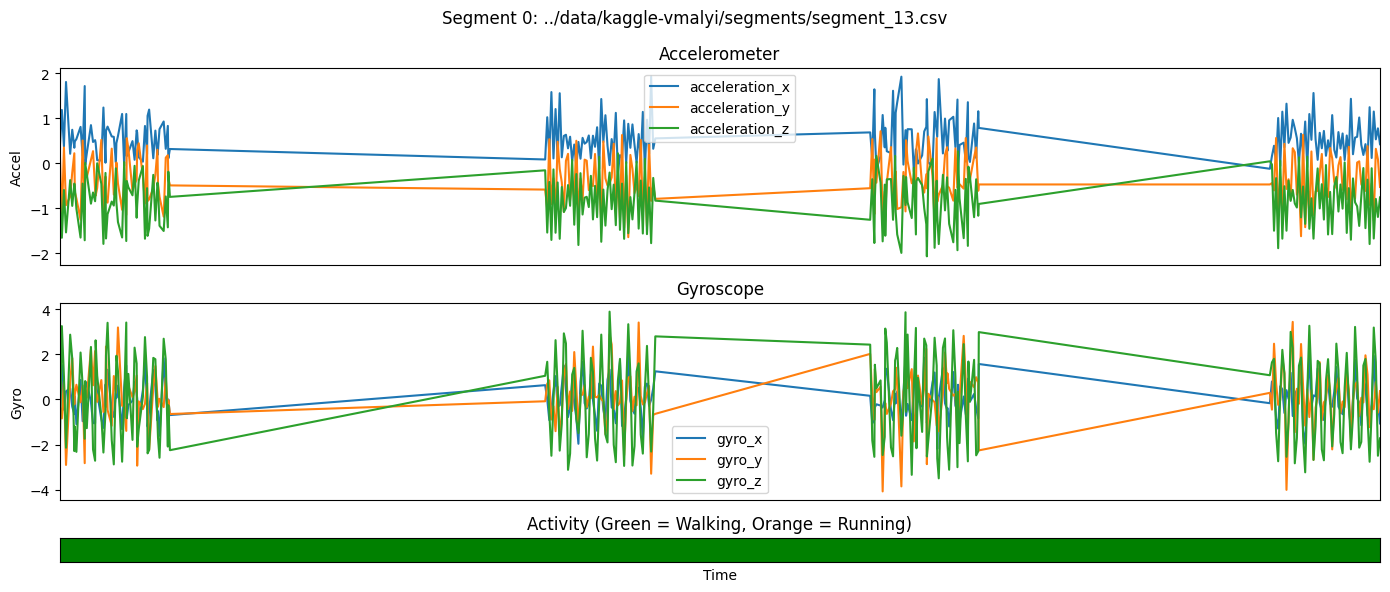

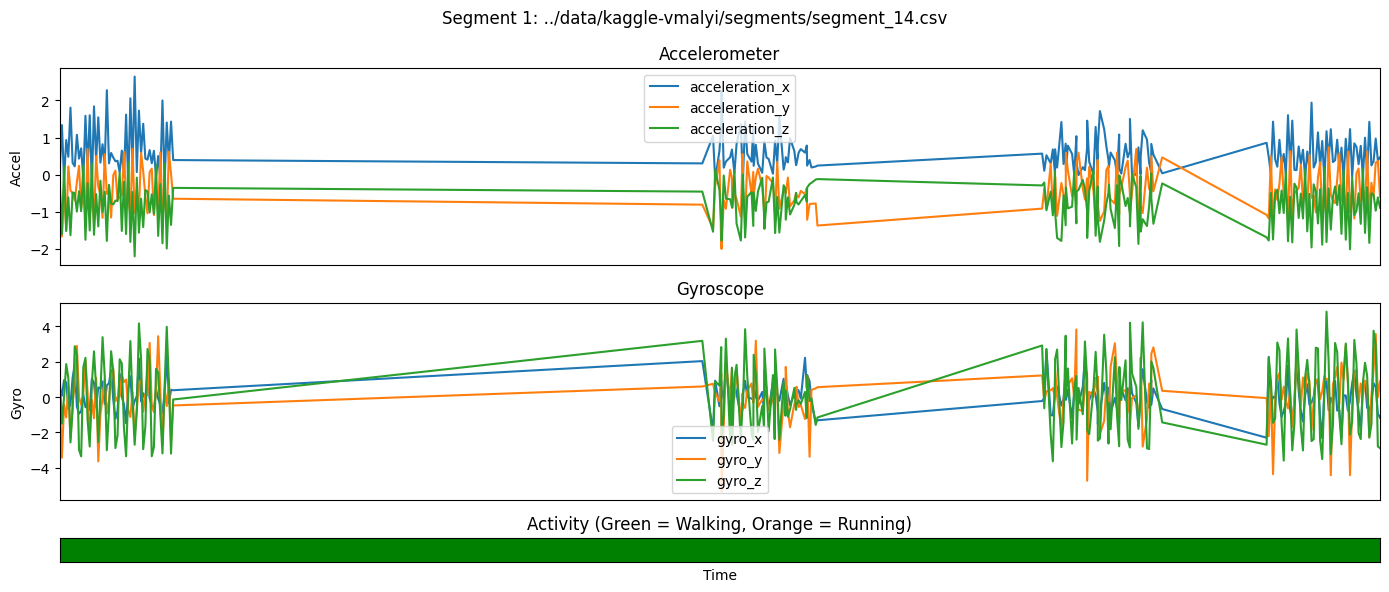

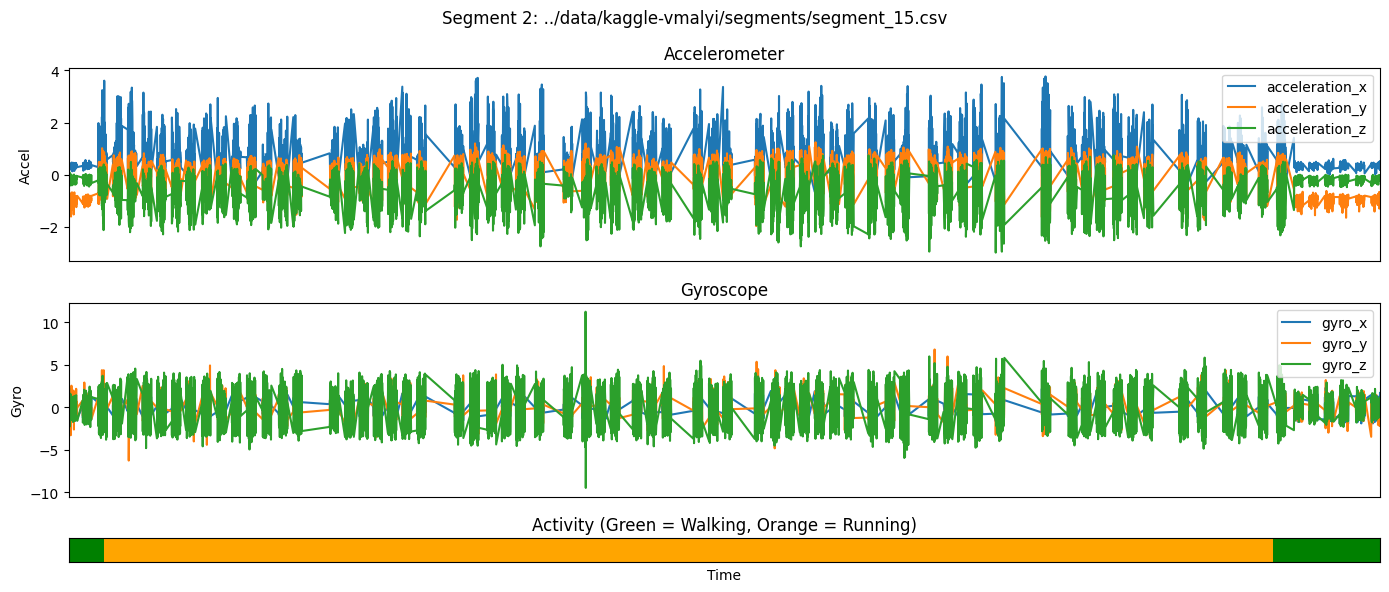

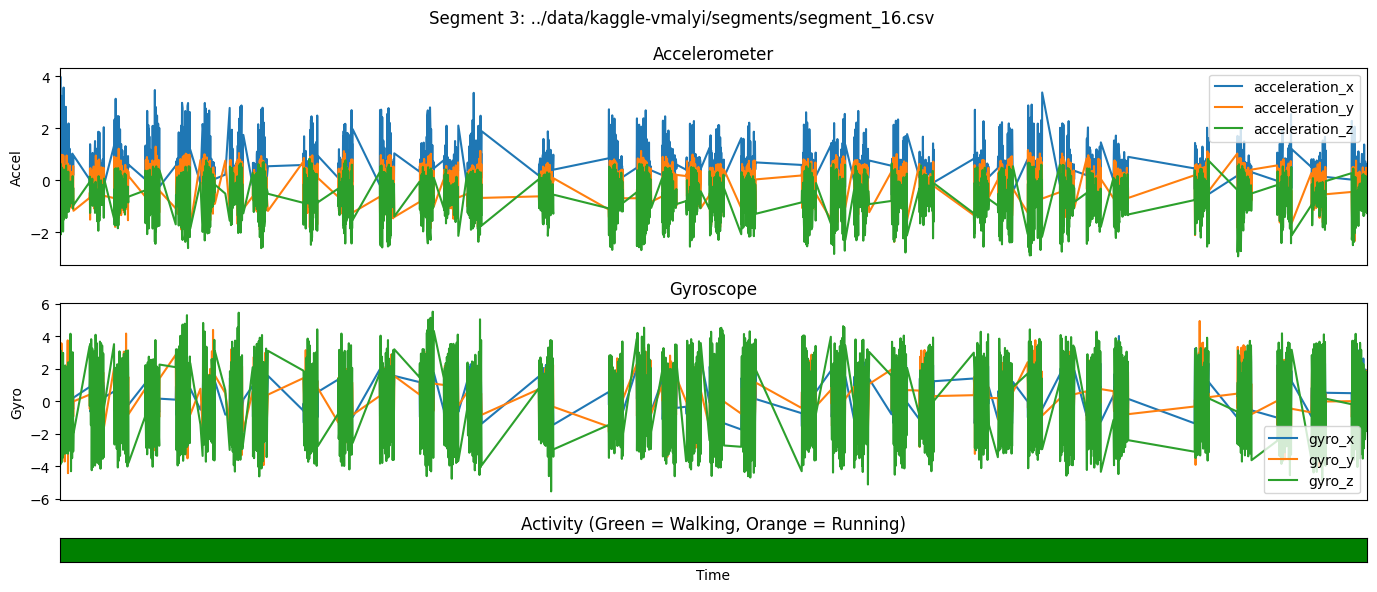

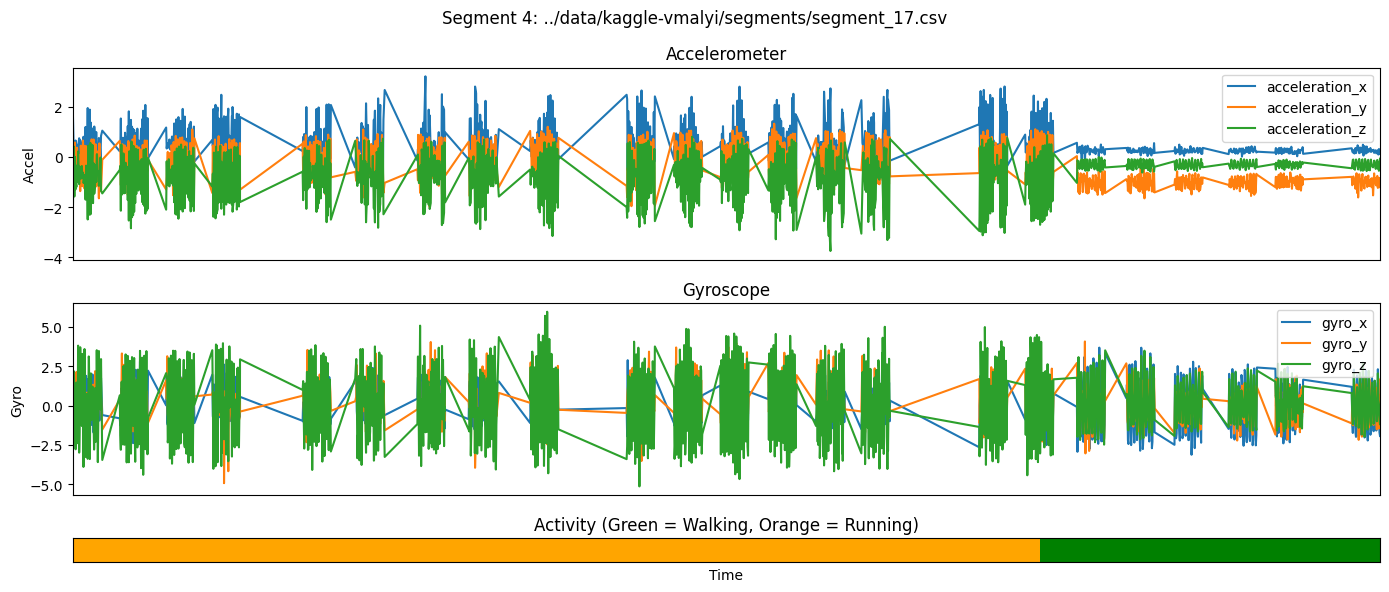

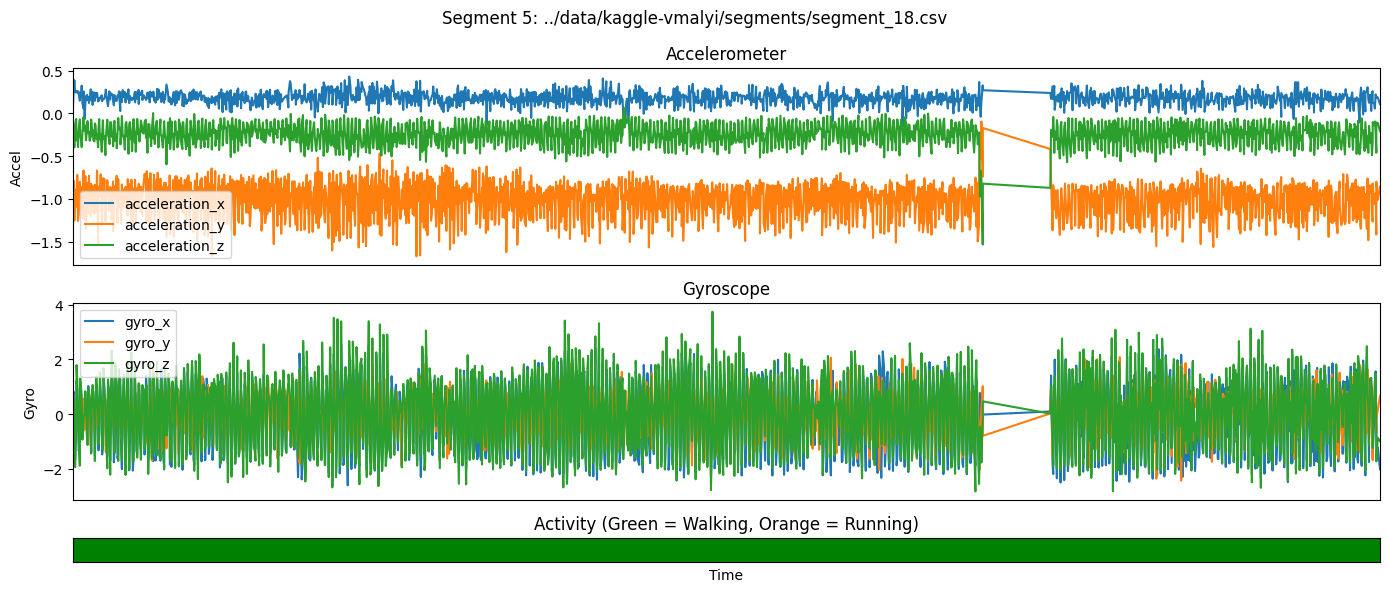

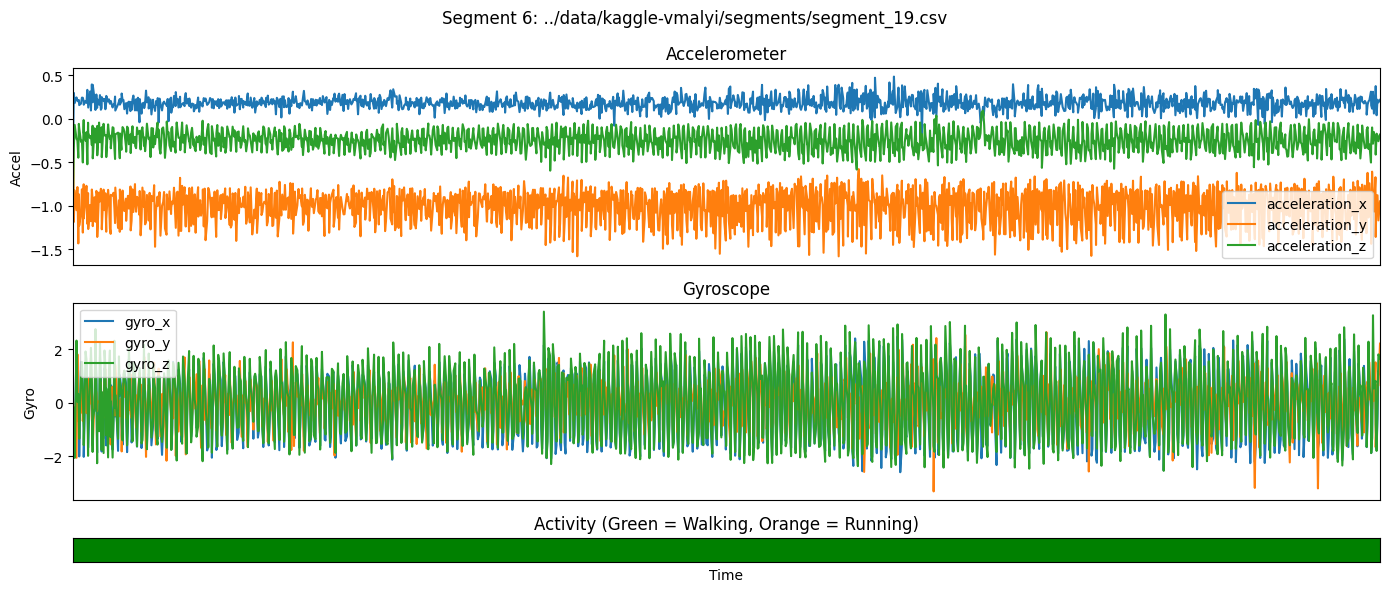

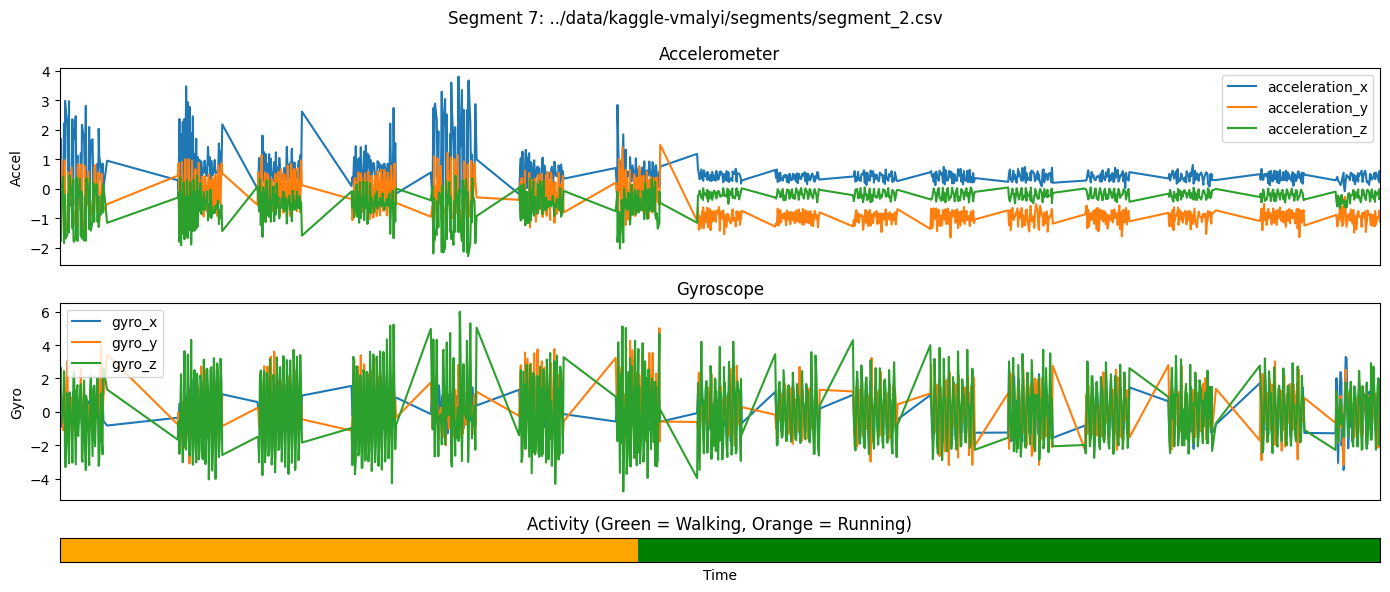

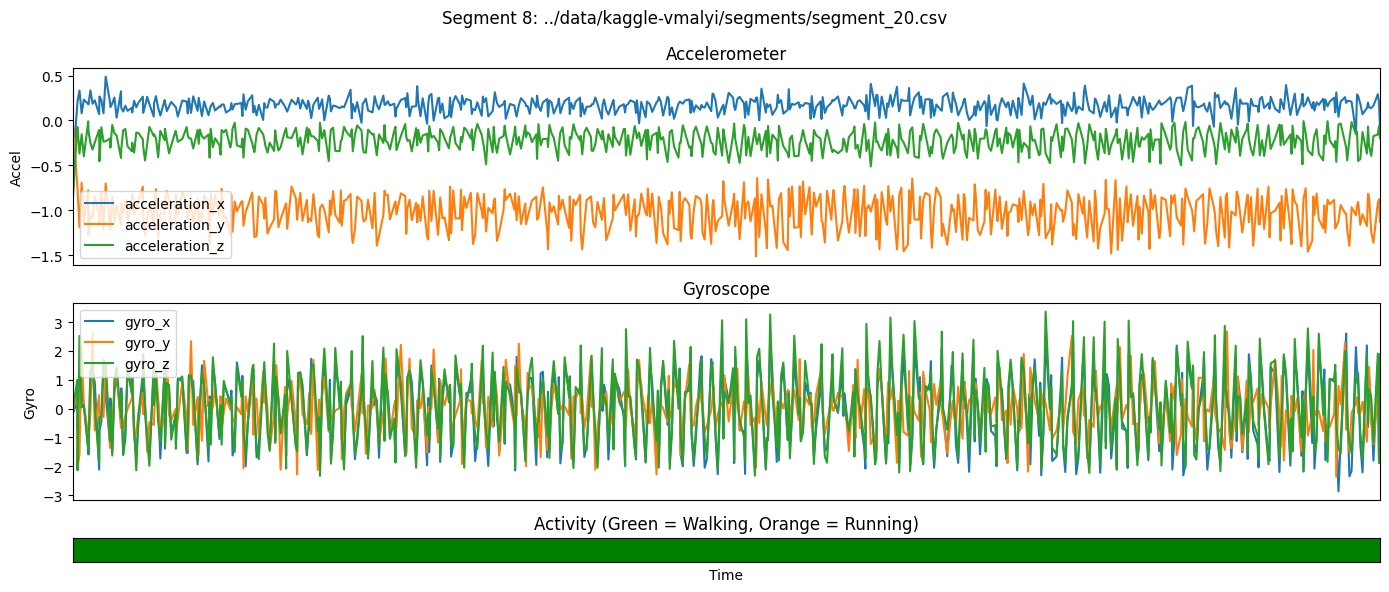

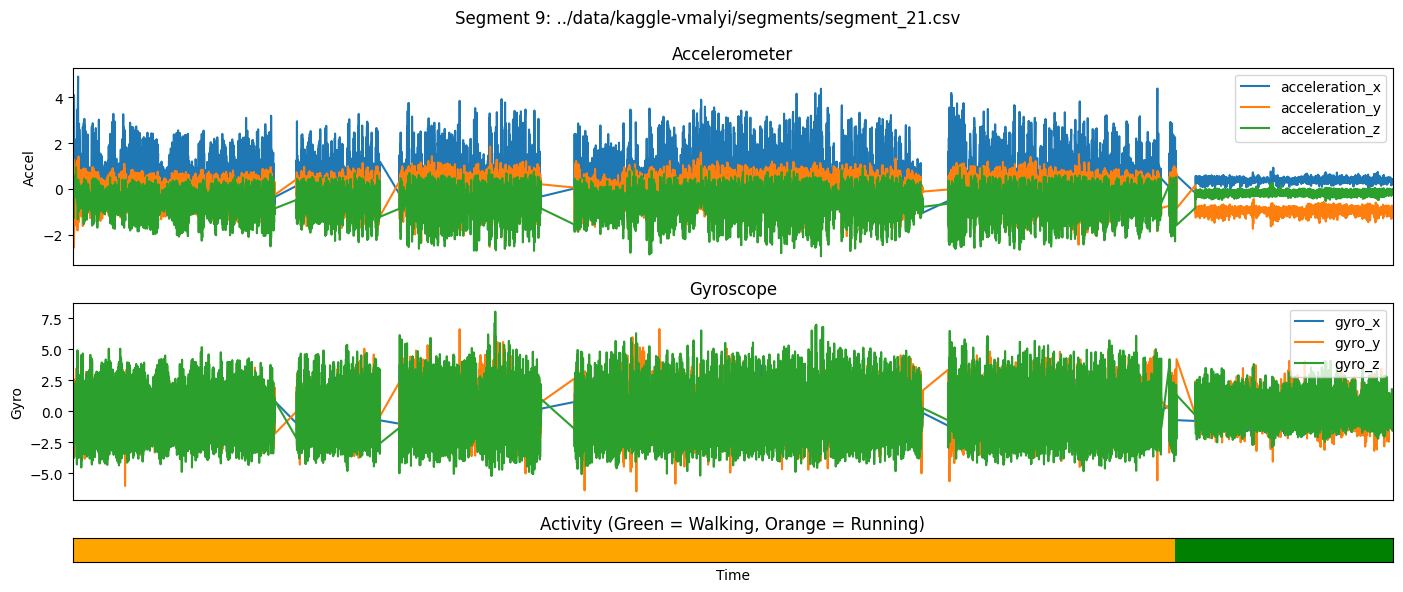

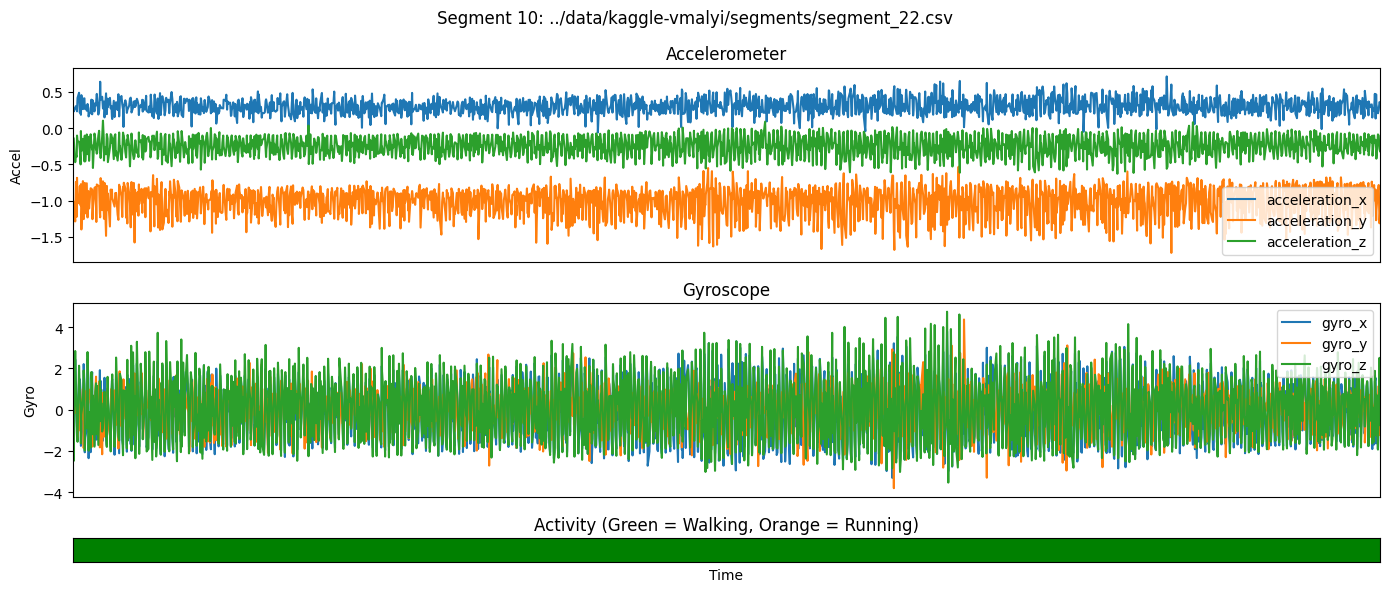

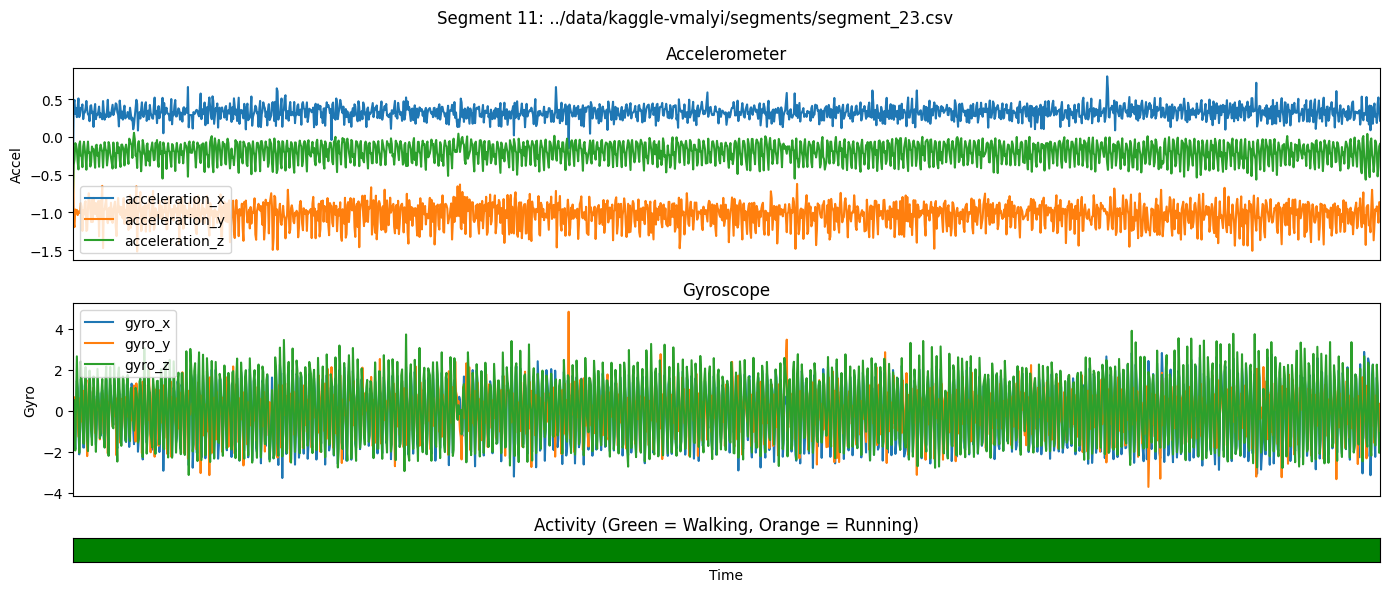

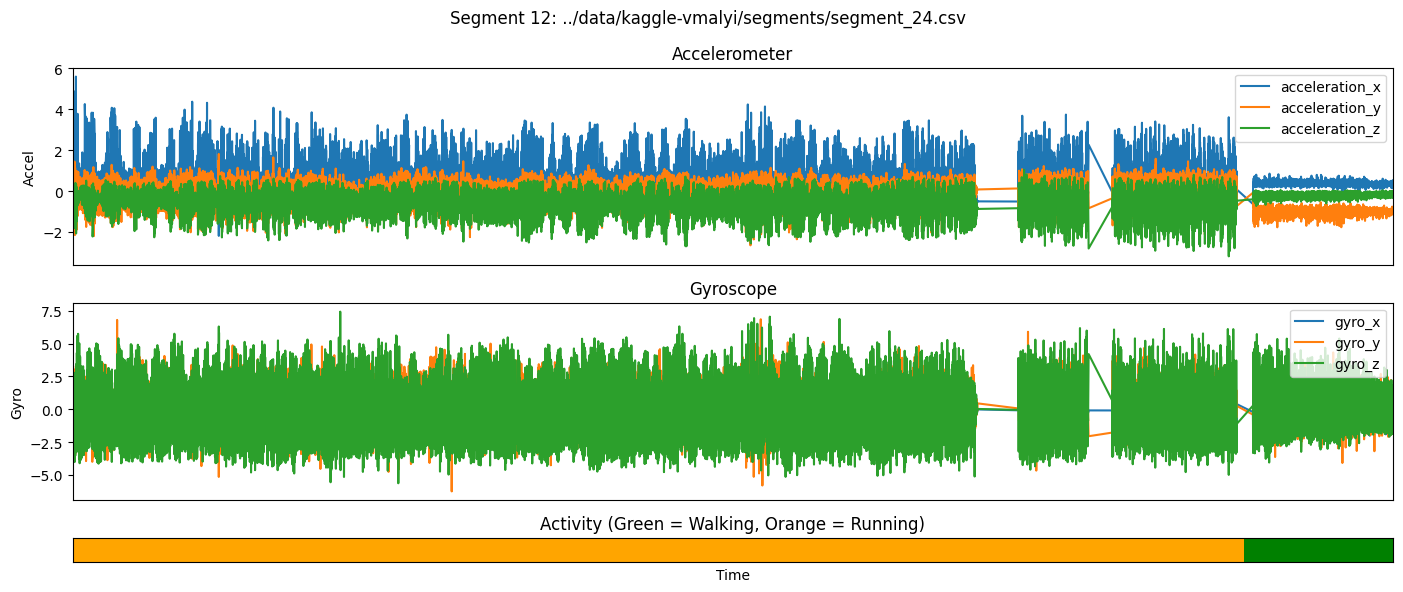

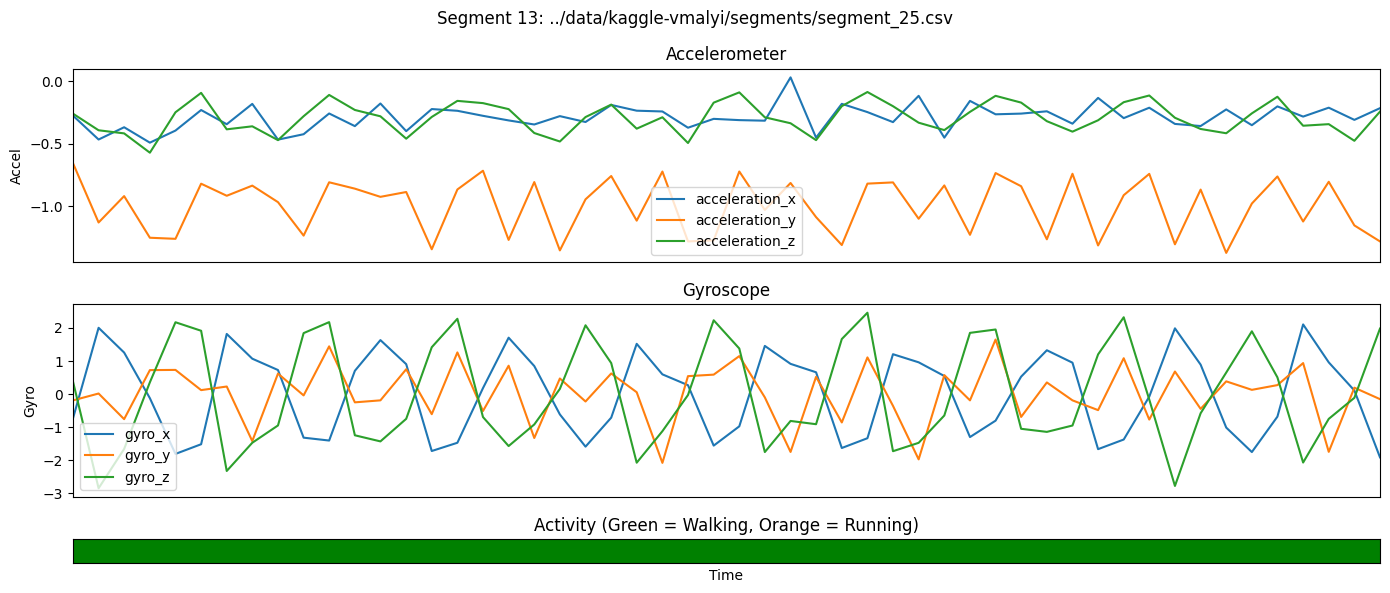

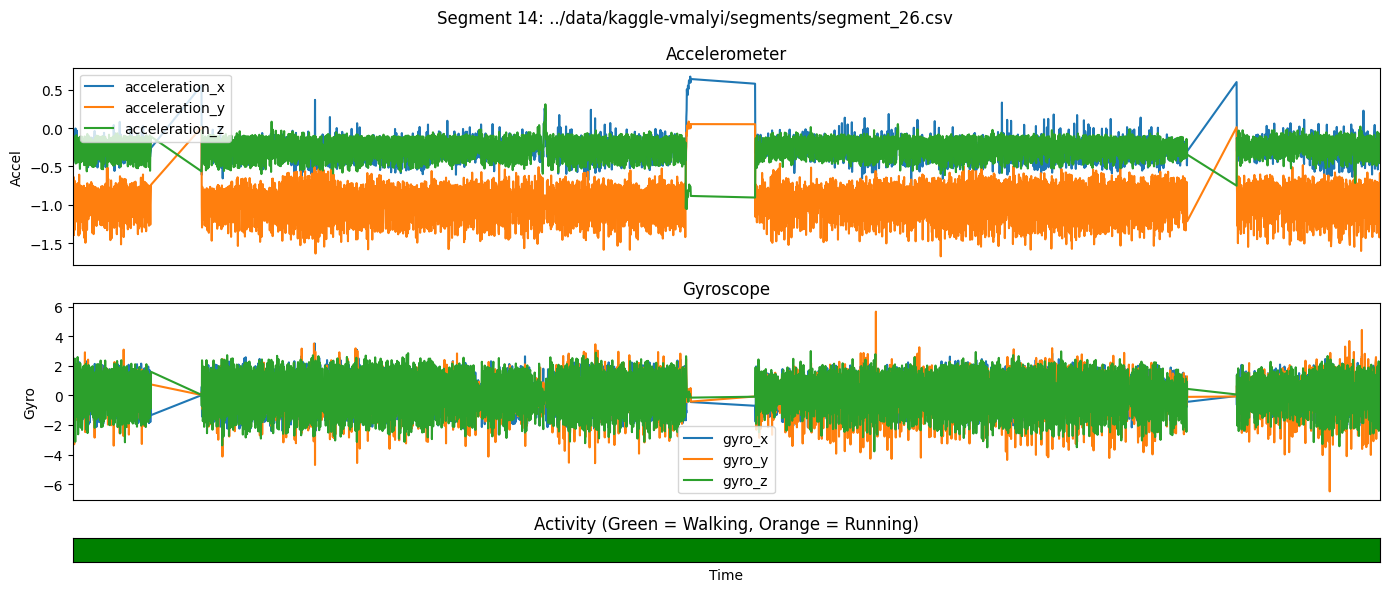

In [39]:

file_start = 5
nr_of_files = 15  # how many segments to show

segment_paths = sorted(glob.glob("../data/kaggle-vmalyi/segments/segment_*.csv"))
selected_files = segment_paths[file_start:file_start + nr_of_files]

for i, file in enumerate(selected_files):
    df = pd.read_csv(file, parse_dates=['timestamp'])

    df['time_sec'] = (df['timestamp'] - df['timestamp'].iloc[0]).dt.total_seconds()

    # Set up figure
    fig, axs = plt.subplots(3, 1, figsize=(14, 6), sharex=True, 
                            gridspec_kw={"height_ratios": [4, 4, 0.5]})
    fig.suptitle(f"Segment {i}: {file}")

    # Accelerometer
    axs[0].set_title("Accelerometer")
    for axis in ['acceleration_x', 'acceleration_y', 'acceleration_z']:
        axs[0].plot(df['time_sec'], df[axis], label=axis)
    axs[0].legend()

    # Gyroscope
    axs[1].set_title("Gyroscope")
    for axis in ['gyro_x', 'gyro_y', 'gyro_z']:
        axs[1].plot(df['time_sec'], df[axis], label=axis)
    axs[1].legend()

    # Activity bar (green = walking [0], orange = running [1])
    activity_array = df['activity'].values.reshape(1, -1)
    cmap = mcolors.ListedColormap(['green', 'orange'])
    axs[2].imshow(activity_array, aspect='auto', cmap=cmap,
                extent=[df['time_sec'].min(), df['time_sec'].max(), 0, 1])
    axs[2].set_yticks([])
    axs[2].set_title("Activity (Green = Walking, Orange = Running)")

    # Sync x-axis to timestamps
    axs[2].set_xticks([])
    axs[1].set_ylabel("Gyro")
    axs[0].set_ylabel("Accel")
    axs[2].set_xlabel("Time")

    plt.tight_layout()
    plt.show()

### Mendleey-Cristiana-Gabriel

- Contains walking info (acc, gyr, mag) for over 200 patients, alongside their user data

In [40]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt

In [41]:
def load_user_session(folder_path, how='outer'):
    """
    Loads and aligns accelerometer, gyroscope, and magnetometer data.
    Returns:
        - merged_df: DataFrame with aligned sensor data
        - metadata: user info dict
    """
    def load_sensor_file(filepath):
        df = pd.read_csv(filepath, sep="\t")

        df.columns = df.columns.str.strip()
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='ms')

        df = df.dropna(subset=['Timestamp'])
        df = df.set_index('Timestamp')
        df = df.resample('20ms').mean().interpolate()
        return df

    sensors = {}
    for sensor in ['accelerometer', 'gyroscope', 'magnetometer']:
        file_path = os.path.join(folder_path, f"{sensor}.txt")
        if os.path.exists(file_path):
            sensors[sensor] = load_sensor_file(file_path)
            # Rename columns to avoid collision (X_acc, Y_acc, etc.)
            sensors[sensor].columns = [f"{col}_{sensor[:4]}" for col in sensors[sensor].columns]

    # Merge all available sensors
    merged_df = None
    for df in sensors.values():
        if merged_df is None:
            merged_df = df
        else:
            merged_df = merged_df.join(df, how=how)

    # Load metadata
    metadata_path = os.path.join(folder_path, "user_data.json")
    metadata = {}
    if os.path.exists(metadata_path):
        with open(metadata_path) as f:
            metadata = json.load(f)

    return merged_df, metadata


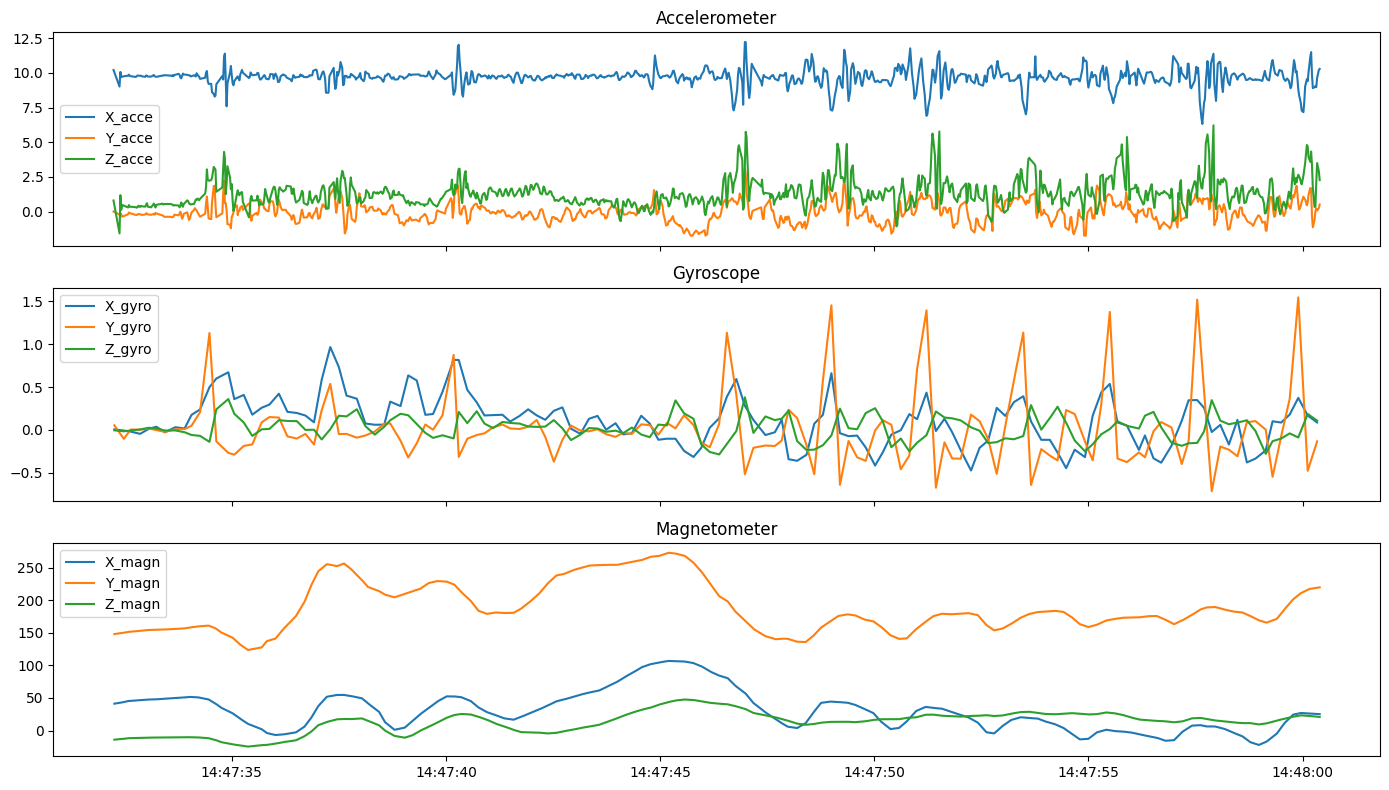

In [42]:
file_to_load = 50

df, meta = load_user_session(f'../data/mendeley-Cristiana-Gabriel/datasets/{file_to_load}')

fig, axs = plt.subplots(3, 1, figsize=(14, 8), sharex=True)


# Accelerometer
axs[0].set_title("Accelerometer")
for col in ['X_acce', 'Y_acce', 'Z_acce']:
    if col in df.columns:
        axs[0].plot(df.index, df[col], label=col)
axs[0].legend()

# Gyroscope
axs[1].set_title("Gyroscope")
for col in ['X_gyro', 'Y_gyro', 'Z_gyro']:
    if col in df.columns:
        axs[1].plot(df.index, df[col], label=col)
axs[1].legend()

# Magnetometer
axs[2].set_title("Magnetometer")
for col in ['X_magn', 'Y_magn', 'Z_magn']:
    if col in df.columns:
        axs[2].plot(df.index, df[col], label=col)
axs[2].legend()

plt.tight_layout()
plt.show()



### Kaggle-malekzadeh

In [43]:
import os
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt

In [44]:
def load_kaggle_malekzadeh_dataset(base_path):
    dataset = []

    # Loop through each activity folder
    for folder in os.listdir(base_path):
        folder_path = os.path.join(base_path, folder)
        if not os.path.isdir(folder_path):
            continue

        # Extract label (e.g., jog, wlk, sit, std)
        label = folder.split("_")[0]

        # Loop through each CSV file
        for csv_file in glob(os.path.join(folder_path, "sub_*.csv")):
            df = pd.read_csv(csv_file)
            df.columns = df.columns.str.strip()  # remove leading/trailing spaces
            dataset.append((df, label, csv_file))

    return dataset


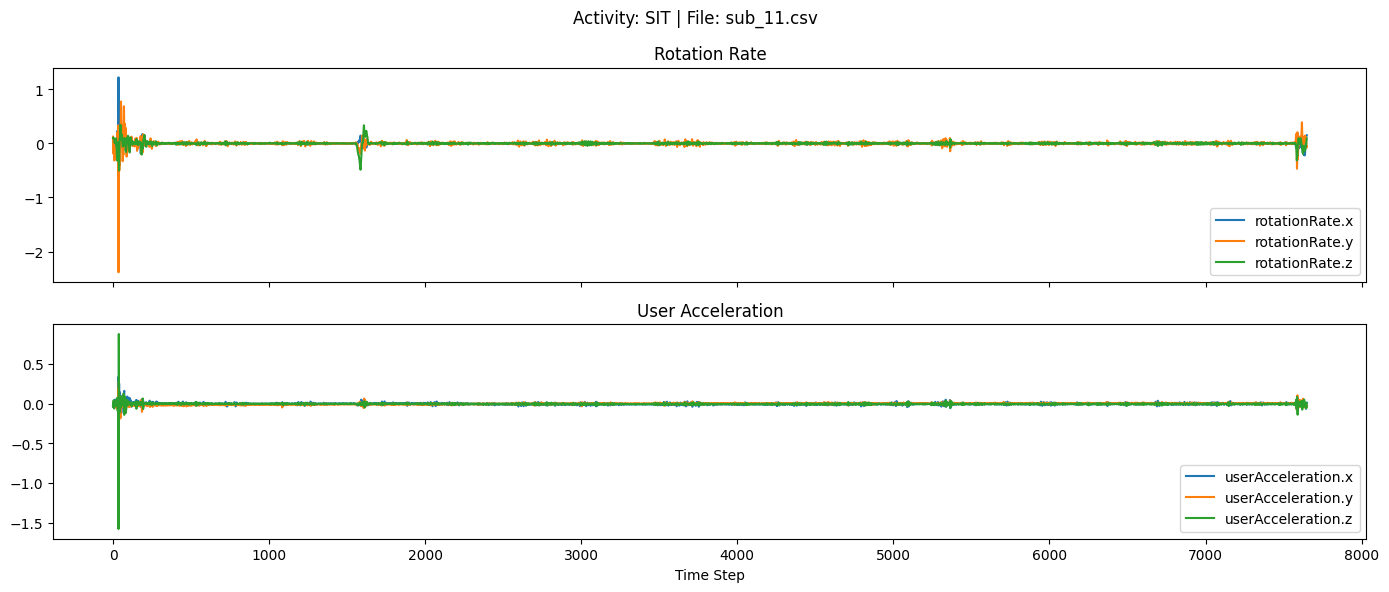

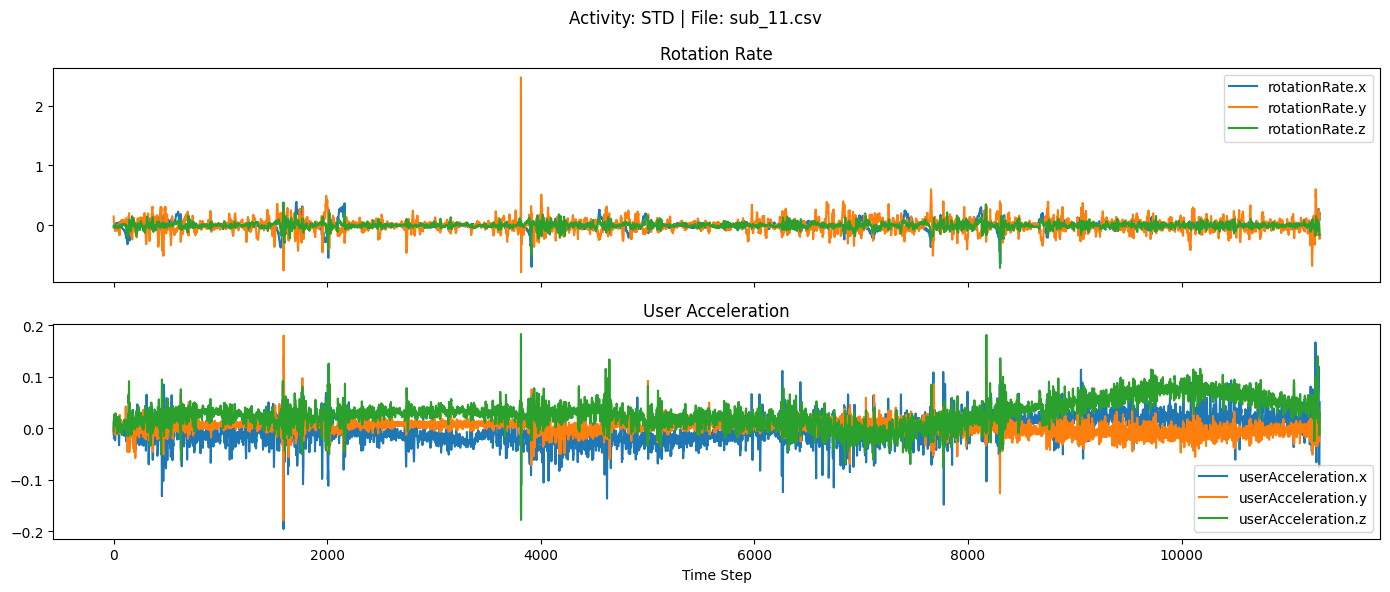

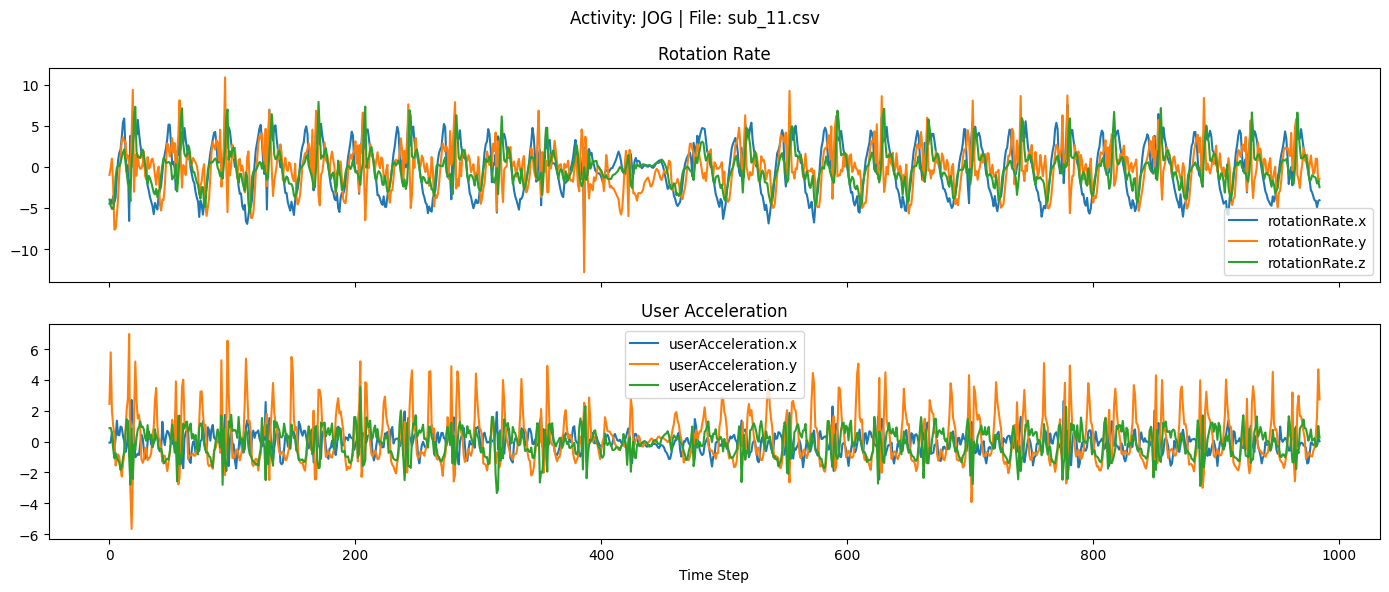

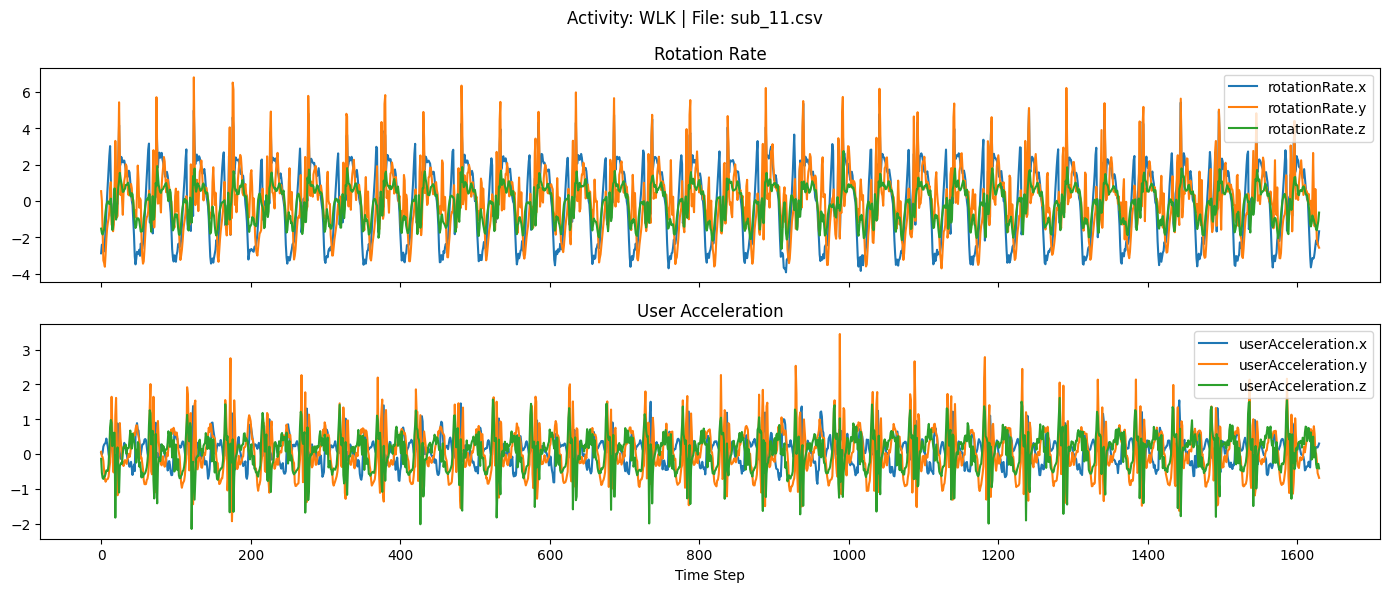

In [45]:
dataset = load_kaggle_malekzadeh_dataset("../data/kaggle-malekzadeh")

# Track which activity labels we've already seen
seen_labels = set()

# Loop through the dataset
for df, label, path in dataset:
    if label in seen_labels:
        continue  # skip duplicates
    
    seen_labels.add(label)

    fig, axs = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    fig.suptitle(f"Activity: {label.upper()} | File: {os.path.basename(path)}")

    # Plot rotationRate
    axs[0].set_title("Rotation Rate")
    for axis in ['rotationRate.x', 'rotationRate.y', 'rotationRate.z']:
        if axis in df.columns:
            axs[0].plot(df.index, df[axis], label=axis)
    axs[0].legend()

    # Plot userAcceleration
    axs[1].set_title("User Acceleration")
    for axis in ['userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z']:
        if axis in df.columns:
            axs[1].plot(df.index, df[axis], label=axis)
    axs[1].legend()

    axs[1].set_xlabel("Time Step")
    plt.tight_layout()
    plt.show()

    # Stop when we've shown all types (edit this set if more labels exist)
    if seen_labels >= {'jog', 'wlk', 'sit', 'std'}:
        break


### Physionet


In [46]:
import os 
import numpy as np
import pandas as pd 
from collections import Counter 
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


In [47]:

ACTIVITIES = {
    1: "Walking",
    2: "Descending Stairs",
    3: "Ascending Stairs",
    4: "Driving",
    77: "Clapping",
    99: "Non-study"
}

data_folder = "../data/physionet/data"
activity_counts_global = Counter()
primary_activities = {}

# Go through each file
for filename in os.listdir(data_folder):
    if filename.endswith(".csv"):
        filepath = os.path.join(data_folder, filename)
        df = pd.read_csv(filepath)

        # Count activities in this file
        counts = df['activity'].value_counts()

        # Store most common activity
        primary_activity = counts.idxmax()
        primary_activities[filename] = primary_activity

        # Update global activity counts
        activity_counts_global.update(df['activity'])


with open('../data/physionet/primary_activities.txt', 'w') as f:
    # Show per-file primary activities
    print("Primary activity per file:")
    f.write("Primary activity per file:\n")
    for file, activity in primary_activities.items():
        print(f"{file}: {ACTIVITIES[activity]}")
        f.write(f"{file}: {ACTIVITIES[activity]}\n")

    # Show global activity distribution
    print("\nGlobal activity distribution across all files:")
    f.write("\nGlobal activity distribution across all files:\n")
    total = sum(activity_counts_global.values())
    for activity, count in activity_counts_global.items():
        pct = count / total * 100
        print(f"Activity {ACTIVITIES[activity]}: {count} samples ({pct:.2f}%)\n")
        f.write(f"Activity {ACTIVITIES[activity]}: {count} samples ({pct:.2f}%)\n")


Primary activity per file:
id5993bf4a.csv: Driving
idc91a49d0.csv: Driving
id3e3e50c7.csv: Driving
idf540d82b.csv: Driving
idb221f542.csv: Driving
id9603e9c3.csv: Non-study
id7c20ee7a.csv: Driving
id86237981.csv: Driving
idd80ac2b4.csv: Walking
id8e66893c.csv: Driving
id00b70b13.csv: Driving
id650857ca.csv: Non-study
id8af5374b.csv: Driving
idecc9265e.csv: Driving
ida61e8ddf.csv: Non-study
id82b9735c.csv: Driving
idbae5a811.csv: Driving
id37a54bbf.csv: Non-study
id687ab496.csv: Driving
id4ea159a8.csv: Driving
id5308a7d6.csv: Driving
id1f372081.csv: Non-study
id1165e00c.csv: Driving
idfc5f05e4.csv: Driving
id34e056c8.csv: Driving
id079c763c.csv: Driving
idf1ce9a0f.csv: Non-study
id1c7e64ad.csv: Driving
idf5e3678b.csv: Non-study
idc735fc09.csv: Driving
idff99de96.csv: Driving
idabd0c53c.csv: Walking

Global activity distribution across all files:
Activity Non-study: 3193794 samples (34.78%)

Activity Clapping: 122515 samples (1.33%)

Activity Walking: 1576845 samples (17.17%)

Activity D

In [48]:
def visualize_file_slice(filepath, target_hz=50, duration_s=15):
    df = pd.read_csv(filepath).copy()
    df = df[df['time_s'] <= duration_s]  # first N seconds
    time = df['time_s'].values

    # Resample time base
    new_time = np.arange(time[0], time[-1], 1 / target_hz)

    # Interpolate all sensor columns
    sensor_cols = ['lw_x', 'lw_y', 'lw_z', 'lh_x', 'lh_y', 'lh_z',
                   'la_x', 'la_y', 'la_z', 'ra_x', 'ra_y', 'ra_z']
    
    df_interp = pd.DataFrame({'time_s': new_time})
    
    for col in sensor_cols:
        f = interp1d(time, df[col], kind='linear', bounds_error=False, fill_value="extrapolate")
        df_interp[col] = f(new_time)

    # Plot
    fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"Resampled @ {target_hz}Hz - {os.path.basename(filepath)}")

    sensors = {
        "Left Wrist": ["lw_x", "lw_y", "lw_z"],
        "Left Hip": ["lh_x", "lh_y", "lh_z"],
        "Left Ankle": ["la_x", "la_y", "la_z"],
        "Right Ankle": ["ra_x", "ra_y", "ra_z"]
    }

    for ax, (label, axes) in zip(axs, sensors.items()):
        for axis in axes:
            ax.plot(df_interp['time_s'], df_interp[axis], label=axis)
        ax.set_title(label)
        ax.legend()

    axs[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

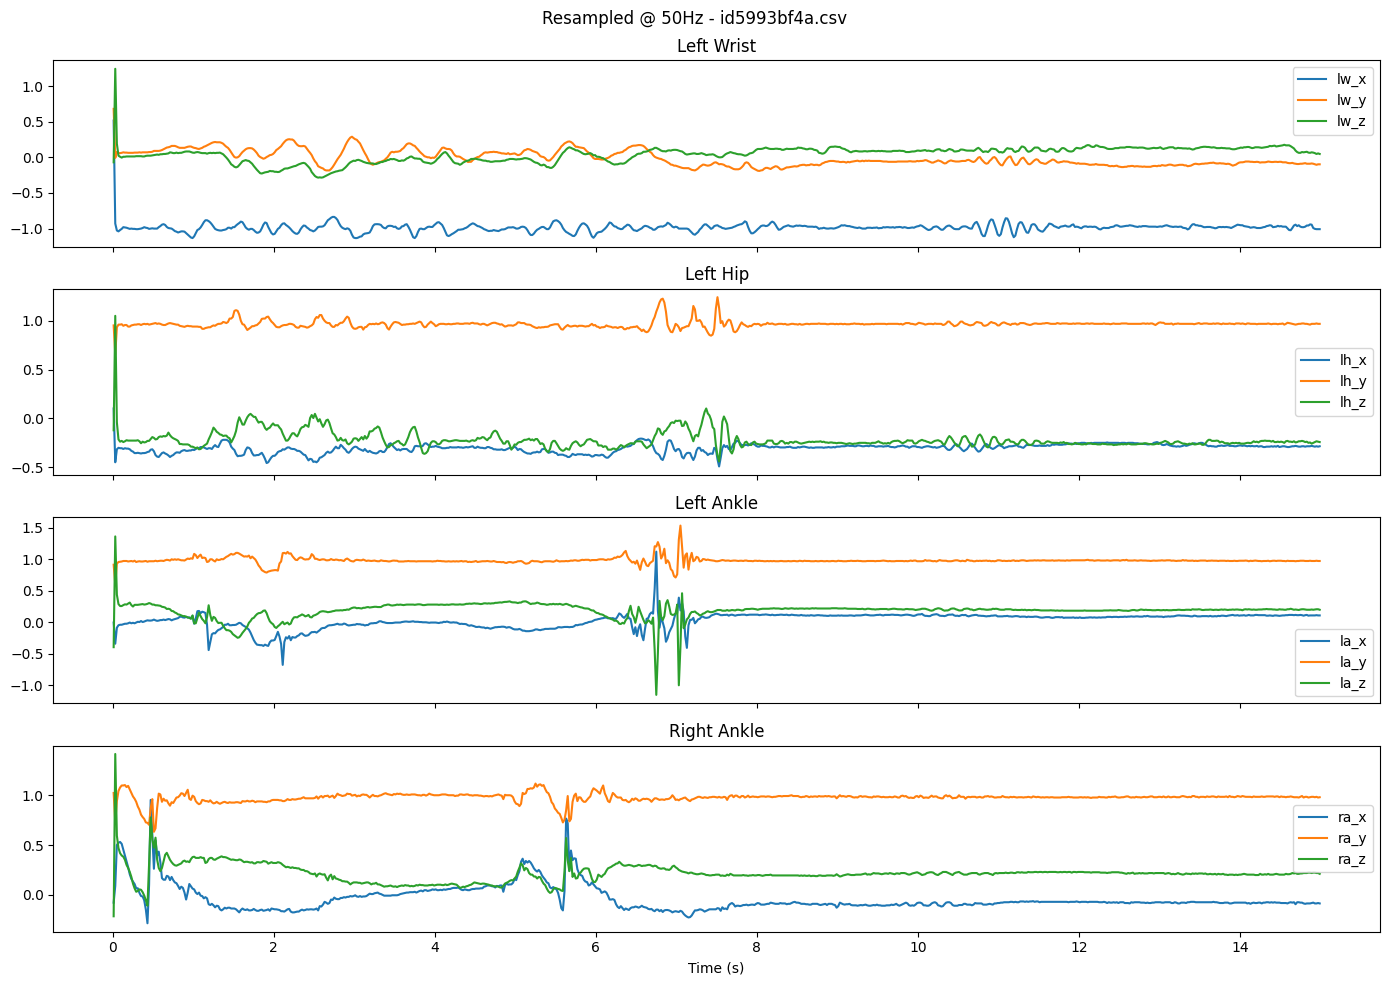

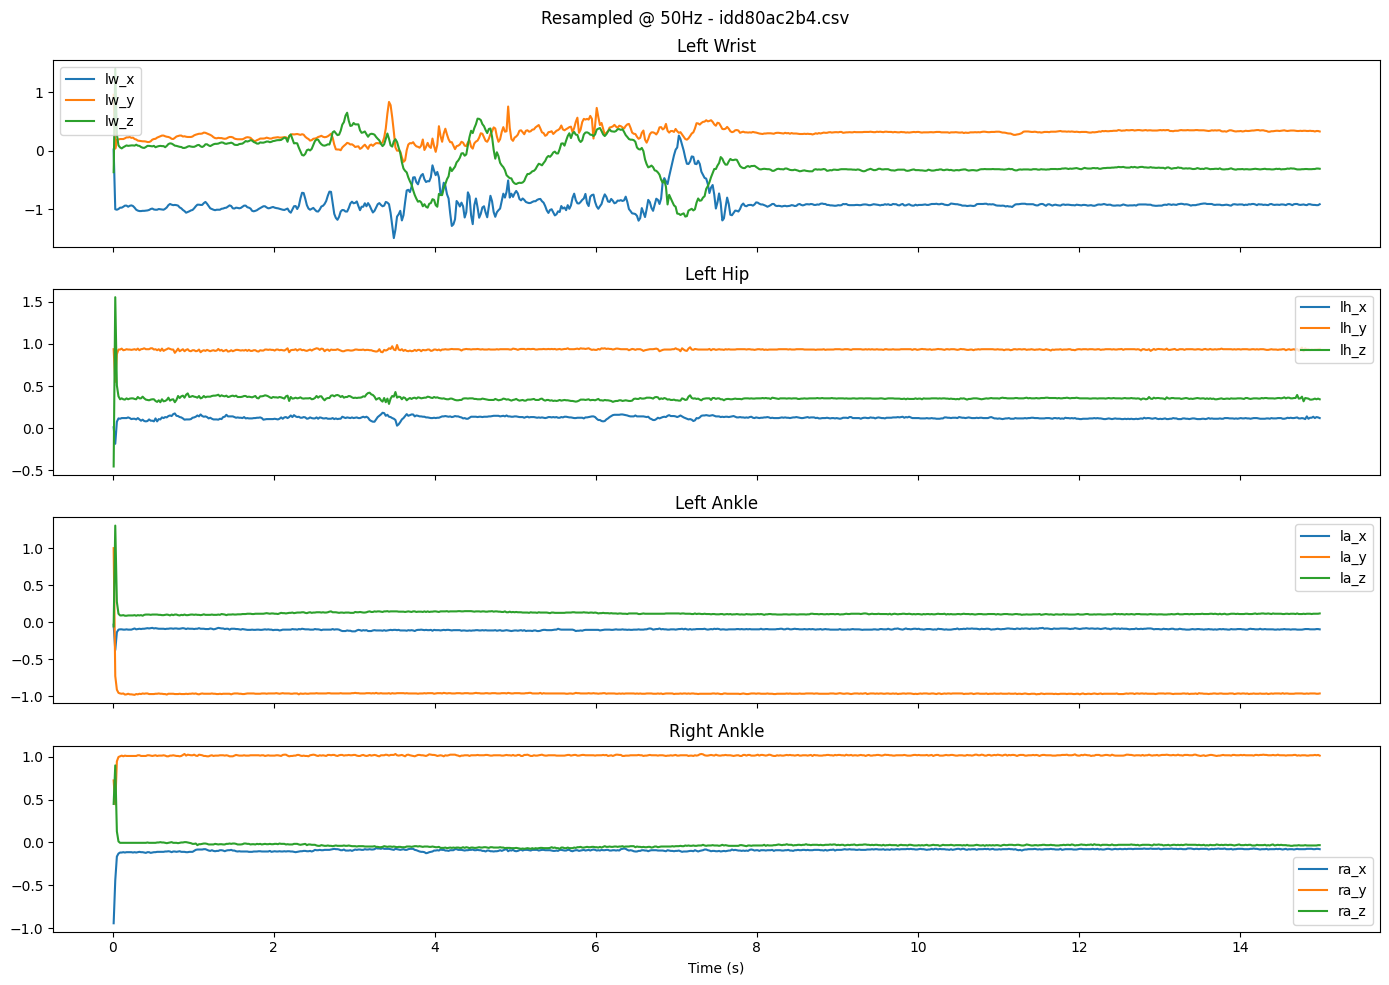

In [49]:
visualize_file_slice("../data/physionet/data/id5993bf4a.csv")
visualize_file_slice("../data/physionet/data/idd80ac2b4.csv")


kaggle-drdataboston

Saving only requried columns in new csv

In [1]:
import os
import pandas as pd

# Paths
input_root = '../data/kaggle-drdataboston/subjects'
output_root = '../data/kaggle-drdataboston/clean_subjects'

# Create output directory if it doesn't exist
os.makedirs(output_root, exist_ok=True)

# Use locationTimestamp_since1970.s. as global timestamp
required_columns = [
    'locationTimestamp_since1970.s.',         # GLOBAL TIMESTAMP
    'motionUserAccelerationX.G.',
    'motionUserAccelerationY.G.',
    'motionUserAccelerationZ.G.',
    'gyroRotationX.rad.s.',
    'gyroRotationY.rad.s.',
    'gyroRotationZ.rad.s.',
    'pedometerNumberofSteps.N.',
    'activity.txt.'
]

# Traverse each subject folder

for filename in os.listdir(input_root):
    if filename.endswith('.csv') or filename.endswith('.txt'):
        file_path = os.path.join(input_root, filename)

        try:
            # Read data
            df = pd.read_csv(file_path)

            # Check that required columns exist
            if not all(col in df.columns for col in required_columns):
                print(f"Skipping {file_path} (missing columns)")
                continue

            # Filter to walking rows
            walking_df = df[df['activity.txt.'] == 'walking']

            # Select relevant columns
            clean_df = walking_df[[
                'locationTimestamp_since1970.s.',
                'motionUserAccelerationX.G.',
                'motionUserAccelerationY.G.',
                'motionUserAccelerationZ.G.',
                'gyroRotationX.rad.s.',
                'gyroRotationY.rad.s.',
                'gyroRotationZ.rad.s.',
                'pedometerNumberofSteps.N.'
            ]]

            # Save with same filename in clean_subjects
            output_file_path = os.path.join(output_root, f"{filename}")
            clean_df.to_csv(output_file_path, index=False)

            print(f"Saved cleaned data to {output_file_path}")

        except Exception as e:
            print(f"Error processing {file_path}: {e}")


Saved cleaned data to ../data/kaggle-drdataboston/clean_subjects/ sub80-rp-s1.csv
Saved cleaned data to ../data/kaggle-drdataboston/clean_subjects/ sub27-rp-s1.csv.csv
Saved cleaned data to ../data/kaggle-drdataboston/clean_subjects/ sub26-rp-s2.csv.csv
Saved cleaned data to ../data/kaggle-drdataboston/clean_subjects/ sub66-lw-s1.csv
Saved cleaned data to ../data/kaggle-drdataboston/clean_subjects/ sub5-lw-s2.csv
Saved cleaned data to ../data/kaggle-drdataboston/clean_subjects/ sub60-rp-s1.csv
Saved cleaned data to ../data/kaggle-drdataboston/clean_subjects/ sub21-lw-s2.csv
Saved cleaned data to ../data/kaggle-drdataboston/clean_subjects/ sub30-rp-s2.csv
Saved cleaned data to ../data/kaggle-drdataboston/clean_subjects/ sub56-rp-s1.csv
Saved cleaned data to ../data/kaggle-drdataboston/clean_subjects/ sub68-rp-s2.csv
Saved cleaned data to ../data/kaggle-drdataboston/clean_subjects/ sub72-rp-s1.csv
Saved cleaned data to ../data/kaggle-drdataboston/clean_subjects/ sub31-lw-s2.csv
Saved cle

Resample to 50HZ (and eliminate double .csv ending)

In [14]:
import os
import pandas as pd

input_root = '../data/kaggle-drdataboston/clean_subjects'
output_root = '../data/kaggle-drdataboston/resampled_subjects'
os.makedirs(output_root, exist_ok=True)

target_freq_hz = 50
resample_period = f"{int(1000 / target_freq_hz)}L"  # 20ms = 50Hz

for filename in os.listdir(input_root):
    if filename.endswith('.csv') or filename.endswith('.txt'):
        file_path = os.path.join(input_root, filename)

        try:
            df = pd.read_csv(file_path)

            # Convert timestamp
            df['timestamp'] = pd.to_datetime(df['locationTimestamp_since1970.s.'], unit='s')
            df.set_index('timestamp', inplace=True)

            # Separate pedometer column before resampling
            pedo = df[['pedometerNumberofSteps.N.']].dropna().copy()
            pedo.reset_index(inplace=True)  # keep timestamp column for merge_asof

            # Drop pedometer from main DF for now
            df = df.drop(columns=['locationTimestamp_since1970.s.', 'pedometerNumberofSteps.N.'], errors='ignore')

            # Resample only sensor data
            df_resampled = df.resample(resample_period).mean().interpolate()

            # Restore timestamp as column
            df_resampled.reset_index(inplace=True)
            df_resampled.rename(columns={'timestamp': 'timestamp_50Hz'}, inplace=True)

            # Merge original pedometer values using nearest timestamp (no interpolation!)
            pedo = pedo.sort_values('timestamp')
            df_resampled = pd.merge_asof(
                df_resampled.sort_values('timestamp_50Hz'),
                pedo,
                left_on='timestamp_50Hz',
                right_on='timestamp',
                direction='nearest',
                tolerance=pd.Timedelta('500ms')  # Accept only reasonably close matches
            )
            df_resampled.drop(columns=['timestamp'], inplace=True)

            # Clean filename
            clean_filename = filename
            if clean_filename.endswith('.csv.csv'):
                clean_filename = clean_filename[:-4]
            clean_filename = clean_filename.strip()

            output_file_path = os.path.join(output_root, clean_filename)
            df_resampled.to_csv(output_file_path, index=False)

            print(f"✅ Resampled and saved: {output_file_path}")

        except Exception as e:
            print(f"❌ Error processing {file_path}: {e}")


✅ Resampled and saved: ../data/kaggle-drdataboston/resampled_subjects/sub80-rp-s1.csv
✅ Resampled and saved: ../data/kaggle-drdataboston/resampled_subjects/sub27-rp-s1.csv
✅ Resampled and saved: ../data/kaggle-drdataboston/resampled_subjects/sub26-rp-s2.csv
✅ Resampled and saved: ../data/kaggle-drdataboston/resampled_subjects/sub66-lw-s1.csv
✅ Resampled and saved: ../data/kaggle-drdataboston/resampled_subjects/sub5-lw-s2.csv
✅ Resampled and saved: ../data/kaggle-drdataboston/resampled_subjects/sub60-rp-s1.csv
✅ Resampled and saved: ../data/kaggle-drdataboston/resampled_subjects/sub21-lw-s2.csv
✅ Resampled and saved: ../data/kaggle-drdataboston/resampled_subjects/sub30-rp-s2.csv
✅ Resampled and saved: ../data/kaggle-drdataboston/resampled_subjects/sub56-rp-s1.csv
✅ Resampled and saved: ../data/kaggle-drdataboston/resampled_subjects/sub68-rp-s2.csv
✅ Resampled and saved: ../data/kaggle-drdataboston/resampled_subjects/sub72-rp-s1.csv
✅ Resampled and saved: ../data/kaggle-drdataboston/resa

In [18]:
import os

clean_root = '../data/kaggle-drdataboston/clean_subjects'
resampled_root = '../data/kaggle-drdataboston/resampled_subjects'

print(f"{'Filename':<50} {'Clean Size (KB)':>15} {'Resampled Size (KB)':>20} {'Change (%)':>15}")

for filename in os.listdir(clean_root):
    clean_path = os.path.join(clean_root, filename)
    
    # Fix possible .csv.csv duplication for comparison
    resampled_filename = filename[:-4] if filename.endswith('.csv.csv') else filename
    resampled_filename = resampled_filename.strip()
    resampled_path = os.path.join(resampled_root, resampled_filename)

    if os.path.exists(resampled_path):
        clean_size_kb = os.path.getsize(clean_path) / 1024
        resampled_size_kb = os.path.getsize(resampled_path) / 1024
        change_pct = ((resampled_size_kb - clean_size_kb) / clean_size_kb) * 100

        print(f"{filename:<50} {clean_size_kb:15.2f} {resampled_size_kb:20.2f} {change_pct:15.2f}")
    else:
        print(f"{filename:<50} {'(missing resampled file)'}")


Filename                                           Clean Size (KB)  Resampled Size (KB)      Change (%)
 sub80-rp-s1.csv                                           5122.64              2996.98          -41.50
 sub27-rp-s1.csv.csv                                       5361.07              3357.22          -37.38
 sub26-rp-s2.csv.csv                                       6062.41              3541.07          -41.59
 sub66-lw-s1.csv                                           5675.88              3492.71          -38.46
 sub5-lw-s2.csv                                            7013.99              4508.28          -35.72
 sub60-rp-s1.csv                                           3568.98              2916.68          -18.28
 sub21-lw-s2.csv                                           6391.46              3972.67          -37.84
 sub30-rp-s2.csv                                           6391.26              3938.08          -38.38
 sub56-rp-s1.csv                                           5821.

Checks existence of files after resampling

In [20]:
import os
import pandas as pd

# Load matrix.csv
matrix_path = '../data/kaggle-drdataboston/matrix.csv'
df = pd.read_csv(matrix_path)

# Folder with resampled files
resampled_folder = '../data/kaggle-drdataboston/resampled_subjects'

# List of all actual filenames in the resampled folder (lowercased for robustness)
actual_files = {f.lower(): f for f in os.listdir(resampled_folder)}

# Columns with filenames
file_columns = [
    'subject_left_waist_session1',
    'subject_right_pocket_session1',
    'subject_left_waist_session2',
    'subject_right_pocket_session2'
]

missing_files = []

# Check each expected file
for idx, row in df.iterrows():
    for col in file_columns:
        filename = str(row[col]).strip()
    
        # Skip missing/empty
        if not filename or filename.lower() == 'nan':
            missing_files.append((idx + 1, col, '[MISSING ENTRY]'))
            continue

        # Handle .csv.csv issue
        if filename.endswith('.csv.csv'):
            filename = filename[:-4]


        # Compare case-insensitively
        if filename.lower() not in actual_files:
            missing_files.append((idx + 1, col, filename))
        else:
            # Uncomment below to see matched files
            # print(f"✅ Found: {actual_files[filename.lower()]}")
            pass

# Report
if missing_files:
    print("🚫 Missing files or invalid entries:")
    for subject_id, col, filename in missing_files:
        print(f"  Row {subject_id} - {col}: {filename}")
else:
    print("✅ All files from matrix.csv exist in resampled_subjects!")


🚫 Missing files or invalid entries:
  Row 2 - subject_left_waist_session1: sub2-lw-s1.csv
  Row 3 - subject_left_waist_session2: sub3-lw-s2.csv
  Row 4 - subject_left_waist_session1: sub4-lw-s1.csv
  Row 5 - subject_right_pocket_session1: sub5-rp-s1.csv
  Row 6 - subject_right_pocket_session1: sub6-rp-s1.csv
  Row 6 - subject_left_waist_session2: sub6-lw-s2.csv
  Row 7 - subject_right_pocket_session1: sub7-rp-s1.csv
  Row 8 - subject_right_pocket_session1: sub8-rp-s1.csv
  Row 9 - subject_right_pocket_session1: sub9-rp-s1.csv
  Row 11 - subject_left_waist_session2: [MISSING ENTRY]
  Row 11 - subject_right_pocket_session2: [MISSING ENTRY]
  Row 12 - subject_right_pocket_session1: sub12-rp-s1.csv
  Row 12 - subject_left_waist_session2: sub12-lw-s2.csv
  Row 13 - subject_left_waist_session2: sub13-lw-s2.csv
  Row 17 - subject_left_waist_session2: [MISSING ENTRY]
  Row 17 - subject_right_pocket_session2: [MISSING ENTRY]
  Row 19 - subject_right_pocket_session2: sub19-rp-s2.csv
  Row 26 - s